# Wavefield · Visco-elastic, generalized standard linear solid (GSLS)

`ViscoElastic` is the attenuating counterpart of `Elastic`: the same
velocity–stress staggered grid, CPML boundaries and free-surface treatment,
with the nearly constant-Q rheology SPECFEM2D (and hence SeisFlows) uses —
$L$ standard linear solids (default 3) whose relaxation times are fixed by the
frequency band. Five model parameters: `vp`, `vs`, `rho`, `Qp`, `Qs`, where
`vp` / `vs` are phase velocities at the reference frequency `f_ref`. All five
carry gradients, on the eager and the compiled (`impl='c'`) backend alike.

The two attenuation controls are **`Qp`** and **`Qs`**: P- and S-wave loss,
set independently. Unlike `ViscoAcoustic` there is no separate phase /
amplitude switch — in a causal dissipative medium dispersion and attenuation
are one complex modulus (section 3).

## 1. Parameters

In [1]:
import warnings
import numpy as np
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', message='Torchinductor does not support.*')

from sweep.equations import ViscoElastic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

shape = (300, 400)             # 2.4 km x 3.2 km at 8 m spacing
dh    = 8.0
dt    = 1.0e-3
nt    = 800
abcn  = 40
freq, delay = 12.0, 0.10
vp_val, vs_val, rho_val = 2500.0, 1400.0, 2000.0
Qp_val, Qs_val = 30.0, 20.0
f_ref = freq                   # vp / vs are the phase velocities at the source's dominant frequency
snapshot_time = 470            # P front: 0.37 s x 2.5 km/s = 925 m < 1.2 km half-height

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.allow_tf32 = False   # eager stencils in full FP32, like impl='c'
print('device:', device)

full = lambda v: torch.full(shape, float(v), dtype=torch.float32, device=device)

# The explicit stress update runs at the UNRELAXED velocities (faster than vp at
# f_ref), so the CFL check uses them: sqrt((lam + 2 mu)_U / rho).
vp_u, _ = ViscoElastic(device=device, f_ref=f_ref).unrelaxed_velocities(
    [full(vp_val), full(vs_val), full(rho_val), full(Qp_val), full(Qs_val)])
vp_unrelaxed = vp_u.max().item()
ppw = vs_val / (2.5 * freq) / dh
cfl = vp_unrelaxed * dt / dh
print(f'ppw(S) at fmax = {ppw:.1f}   unrelaxed vp = {vp_unrelaxed:.0f} m/s   CFL = {cfl:.3f}')
assert ppw >= 5.0 and cfl <= 0.5

# A vertical force radiates both P (lobes up / down) and S (lobes left / right).
src_iz, src_ix = shape[0] // 2, shape[1] // 2
sources = np.array([[src_ix, src_iz]], dtype=np.int64)
off = np.arange(25, 120, 5)                                   # 200 .. 920 m
rec_up = np.stack([np.full_like(off, src_ix), src_iz - off], -1)     # through the P lobe
rec_right = np.stack([src_ix + off, np.full_like(off, src_iz)], -1)  # through the S lobe
receivers = np.concatenate([rec_up, rec_right])[None]
offsets = off * dh

t = np.arange(nt, dtype=np.float32) * dt - delay
wavelet = torch.tensor(ricker(t, f=freq).astype(np.float32), device=device)

device: cuda


ppw(S) at fmax = 5.8   unrelaxed vp = 2570 m/s   CFL = 0.321


## 2. Qp and Qs: one quadrant per switch

Same medium, same source — only `Qp` and `Qs` differ. The medium is uniform, so
one snapshot can carry all four runs: each quadrant comes from a different
combination, and every seam flips exactly one switch. The **vertical seam flips
`Qp`** and runs through the two P lobes; the **horizontal seam flips `Qs`** and
runs through the two S lobes.

In [2]:
INF = float('inf')
COMBOS = [((INF, INF),       'elastic (Q = inf)'),
          ((Qp_val, INF),    f'Qp = {Qp_val:.0f} only'),
          ((INF, Qs_val),    f'Qs = {Qs_val:.0f} only'),
          ((Qp_val, Qs_val), f'Qp = {Qp_val:.0f}, Qs = {Qs_val:.0f}')]

runs = {}
for (qp, qs), label in COMBOS:
    models = [full(vp_val), full(vs_val), full(rho_val), full(qp), full(qs)]
    solver = PropTorch(ViscoElastic(device=device, f_ref=f_ref), shape=shape, dh=dh, dt=dt,
                       nt=nt, abcn=abcn, source_type=['vz'], receiver_type=['vz'],
                       impl='eager', use_ckpt=False)
    with torch.no_grad():
        rec, snaps = solver(wavelet, sources, receivers, models=models,
                            return_wavefield=True, snapshot_times=[snapshot_time])
    z_lo, z_hi, x_lo, x_hi = solver.pad
    vz = snaps[-1, 1, 0, 0].cpu().numpy()          # (snapshot, field, shot, 1, z, x); field 1 = vz
    runs[(qp, qs)] = (label, rec[0, :, :, 0].T.cpu().numpy(),
                      vz[z_lo:vz.shape[0] - z_hi, x_lo:vz.shape[1] - x_hi])
    line = f'{label:22s}'
    if device.type == 'cuda':                      # the compiled backend, same run
        solver_c = PropTorch(ViscoElastic(device=device, f_ref=f_ref), shape=shape, dh=dh,
                             dt=dt, nt=nt, abcn=abcn, source_type=['vz'],
                             receiver_type=['vz'], impl='c')
        with torch.no_grad():
            rec_c = solver_c(wavelet, sources, receivers, models=models)
        line += f'   impl=c vs eager record rel_l2 = {((rec_c - rec).norm() / rec.norm()).item():.1e}'
    print(line)

elastic (Q = inf)        impl=c vs eager record rel_l2 = 6.4e-07


Qp = 30 only             impl=c vs eager record rel_l2 = 5.5e-07


Qs = 20 only             impl=c vs eager record rel_l2 = 5.5e-07


Qp = 30, Qs = 20         impl=c vs eager record rel_l2 = 3.4e-07


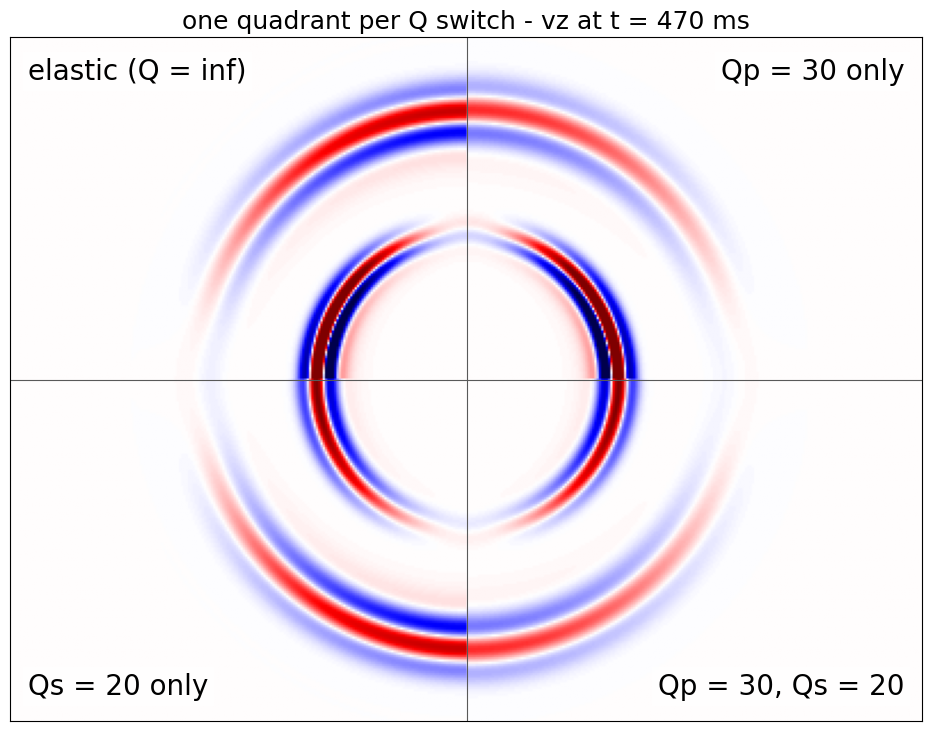

In [3]:
# The medium is uniform, so the wavefield is symmetric about both seams -
# stitch ONE image from a quadrant of each run.
Z, X = np.ogrid[:shape[0], :shape[1]]
top, left = Z < src_iz, X < src_ix
masks = [top & left, top & ~left, ~top & left, ~top & ~left]
composite = np.empty(shape, np.float32)
for (key, _), m in zip(COMBOS, masks):
    composite[m] = runs[key][2][m]

clip = np.percentile(np.abs(runs[(INF, INF)][2]), 99)
fig, ax = plt.subplots(figsize=(9.5, 7.2), constrained_layout=True)
ax.imshow(composite, cmap='seismic', vmin=-clip, vmax=clip, aspect='equal')
ax.axvline(src_ix, color='0.35', lw=0.8); ax.axhline(src_iz, color='0.35', lw=0.8)
corners = [(0.02, 0.97, 'left', 'top'), (0.98, 0.97, 'right', 'top'),
           (0.02, 0.03, 'left', 'bottom'), (0.98, 0.03, 'right', 'bottom')]
for ((_, label), (cx, cy, ha, va)) in zip(COMBOS, corners):
    ax.text(cx, cy, label, transform=ax.transAxes, ha=ha, va=va, fontsize=20,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f'one quadrant per Q switch - vz at t = {snapshot_time * dt * 1e3:.0f} ms', fontsize=18)
plt.show()

The traces make it quantitative. Up through the P lobe only `Qp` matters (the
two runs with `Qp = 30` coincide, as do the two without); to the right through
the S lobe only `Qs` does. Dividing by the elastic run cancels spreading and the
source, so the peak ratio can be compared with the constant-Q loss
$\exp(-\pi f\, r / (Q\, v))$ at the dominant frequency (a broadband wavelet
downshifts as it attenuates, so the measured decay sits slightly below it).

P, straight up   peak ratio 0.635   constant-Q theory at 12 Hz 0.669
S, to the right  peak ratio 0.317   constant-Q theory at 12 Hz 0.341


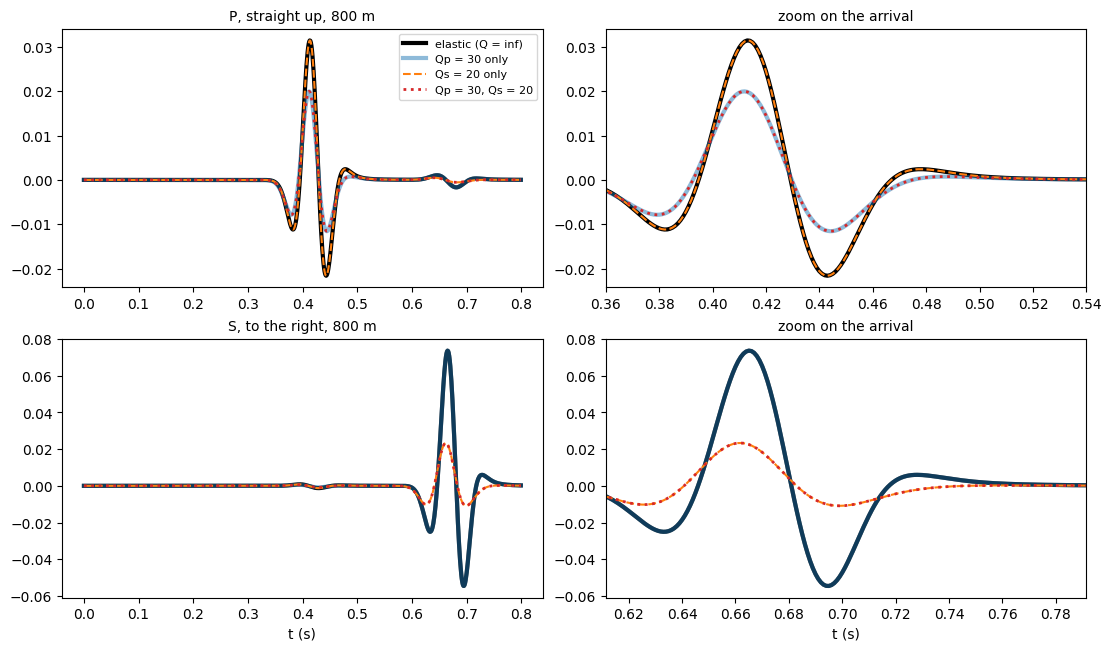

In [4]:
i = int(np.argmin(np.abs(offsets - 800.0)))
t_axis = np.arange(nt) * dt
# identical pairs overlap: thick translucent solids underneath, dashed / dotted on top
styles = [dict(color='k', ls='-', lw=3.0), dict(color='C0', ls='-', lw=3.0, alpha=0.5),
          dict(color='C1', ls='--', lw=1.5), dict(color='C3', ls=':', lw=2.0)]
lanes = [(i, vp_val, Qp_val, 'P, straight up'), (len(off) + i, vs_val, Qs_val, 'S, to the right')]

fig, axes = plt.subplots(2, 2, figsize=(11, 6.4), constrained_layout=True)
for row, (ridx, v, q, name) in enumerate(lanes):
    t_arr = delay + offsets[i] / v
    for (key, label), st in zip(COMBOS, styles):
        tr = runs[key][1][ridx]
        axes[row, 0].plot(t_axis, tr, label=label, **st)
        axes[row, 1].plot(t_axis, tr, **st)
    axes[row, 0].set_title(f'{name}, {offsets[i]:.0f} m', fontsize=10)
    axes[row, 1].set_xlim(t_arr - 0.06, t_arr + 0.12)
    axes[row, 1].set_title('zoom on the arrival', fontsize=10)
    ratio = np.abs(runs[(Qp_val, Qs_val)][1][ridx]).max() / np.abs(runs[(INF, INF)][1][ridx]).max()
    print(f'{name:16s} peak ratio {ratio:.3f}   constant-Q theory at {freq:.0f} Hz '
          f'{np.exp(-np.pi * freq * offsets[i] / (q * v)):.3f}')
axes[0, 0].legend(fontsize=8)
for ax in axes[1]:
    ax.set_xlabel('t (s)')
plt.show()

## 3. Why there is no phase / amplitude switch

One complex modulus,
$M(\omega) = M_R\left(1 + \sum_l \tau_l\,\dfrac{i\omega\tau_{\sigma l}}{1 + i\omega\tau_{\sigma l}}\right)$,
gives both effects at once: its imaginary part is the loss
($Q = \mathrm{Re}\,M / \mathrm{Im}\,M$) and the frequency dependence of its
real part is the dispersion. Causality
(Kramers–Kronig) forbids one without the other, so a GSLS can only be steered
through `Qp` / `Qs` (how much), `f_band` (over which band Q is held constant)
and `f_ref` (at which frequency `vp` / `vs` are the true phase velocities).
Below: the realised Q and phase velocity of the `Qp = 30` P wave.

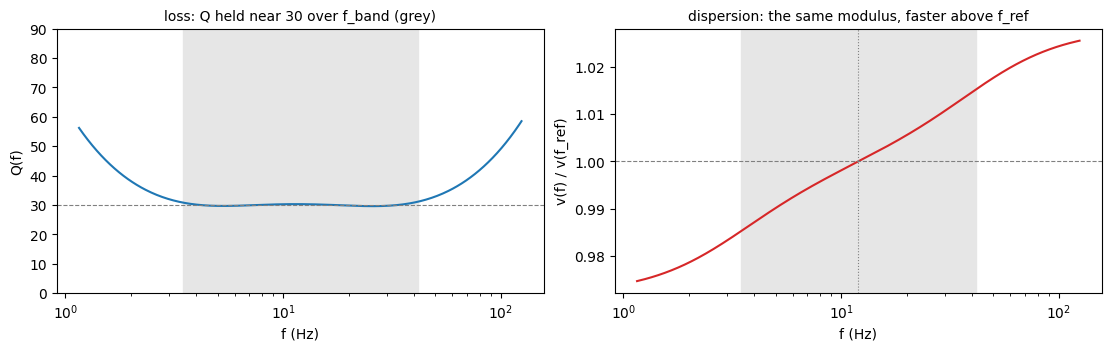

In [5]:
eq = ViscoElastic(f_ref=f_ref)
f = np.geomspace(eq.f_band[0] / 3, eq.f_band[1] * 3, 400)
tau = eq.fit.tau_np(Qp_val)
m = eq.fit.modulus_ratio(tau, f)                     # M(w) / M_R
m_ref = eq.fit.modulus_ratio(tau, np.array([f_ref]))
v_ratio = np.real(m_ref ** -0.5) / np.real(m ** -0.5)   # phase velocity / its value at f_ref

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True)
axes[0].semilogx(f, m.real / m.imag, 'C0')
axes[0].axhline(Qp_val, color='0.5', ls='--', lw=0.8)
axes[0].set_ylabel('Q(f)'); axes[0].set_ylim(0, 3 * Qp_val)
axes[1].semilogx(f, v_ratio, 'C3')
axes[1].axhline(1.0, color='0.5', ls='--', lw=0.8); axes[1].axvline(f_ref, color='0.5', ls=':', lw=0.8)
axes[1].set_ylabel('v(f) / v(f_ref)')
for ax in axes:
    ax.axvspan(*eq.f_band, color='0.9', zorder=0)
    ax.set_xlabel('f (Hz)')
axes[0].set_title(f'loss: Q held near {Qp_val:.0f} over f_band (grey)', fontsize=10)
axes[1].set_title('dispersion: the same modulus, faster above f_ref', fontsize=10)
plt.show()

## Notes

- **`Qp = Qs = inf` is `Elastic`**: bit for bit with the uncompiled eager step
  (`use_compile=False`), to float rounding otherwise (compiled eager, `impl='c'`).
- **Backends.** Eager autograd everywhere; `impl='c'` implements the forward and
  the `full`, chunk- and recursive-checkpoint backwards with a hand-derived
  adjoint for all five models (checkpointed gradients are bitwise equal to
  `full`). **Boundary saving is refused** — the attenuation is dissipative, so
  reverse-time reconstruction is unstable; the compiled default falls back to
  full storage. Topography and domain decomposition are not supported.
- **Stability.** Choose `dt` from the CFL condition on the *unrelaxed*
  velocity (section 1); `Q` must stay above `eq.q_min` (about 1.3 for 3
  mechanisms), below which the constant-Q fit would need a negative relaxation
  strength.
- **`f_band`** defaults to a factor 12 around `f_ref` (SPECFEM's choice); for
  inversion set it to the band being inverted.

## References

Robertsson, J. O., Blanch, J. O. and Symes, W. W., 1994, Viscoelastic
finite-difference modeling: Geophysics, 59(9), 1444–1456,
[doi:10.1190/1.1443701](https://doi.org/10.1190/1.1443701) — the
staggered-grid memory-variable scheme `ViscoElastic` solves.

Emmerich, H. and Korn, M., 1987, Incorporation of attenuation into
time-domain computations of seismic wave fields: Geophysics, 52(9),
1252–1264, [doi:10.1190/1.1442386](https://doi.org/10.1190/1.1442386) —
the constant-Q fit: linear least squares for the relaxation strengths at
fixed, log-spaced relaxation frequencies.